In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
CSV = "Motor_Vehicle_Collisions_-_Crashes_20260926.csv"
YEARS = [2023, 2024, 2025]

# Load only the columns the map needs (much faster than the whole file)
pts = pd.read_csv(CSV, usecols=["CRASH DATE", "BOROUGH", "LATITUDE", "LONGITUDE"], low_memory=False)
pts["year"] = pd.to_datetime(pts["CRASH DATE"]).dt.year
pts = pts[pts["year"].isin(YEARS)]
print(f"{len(pts):,} crashes in {YEARS[0]}–{YEARS[-1]}")

# Keep only coordinates inside NYC (some are blank, 0, or recorded in the wrong place)
pts = pts[pts["LATITUDE"].between(40.49, 40.92) & pts["LONGITUDE"].between(-74.27, -73.68)]
print(f"{len(pts):,} have usable coordinates")

273,469 crashes in 2023–2025
255,410 have usable coordinates


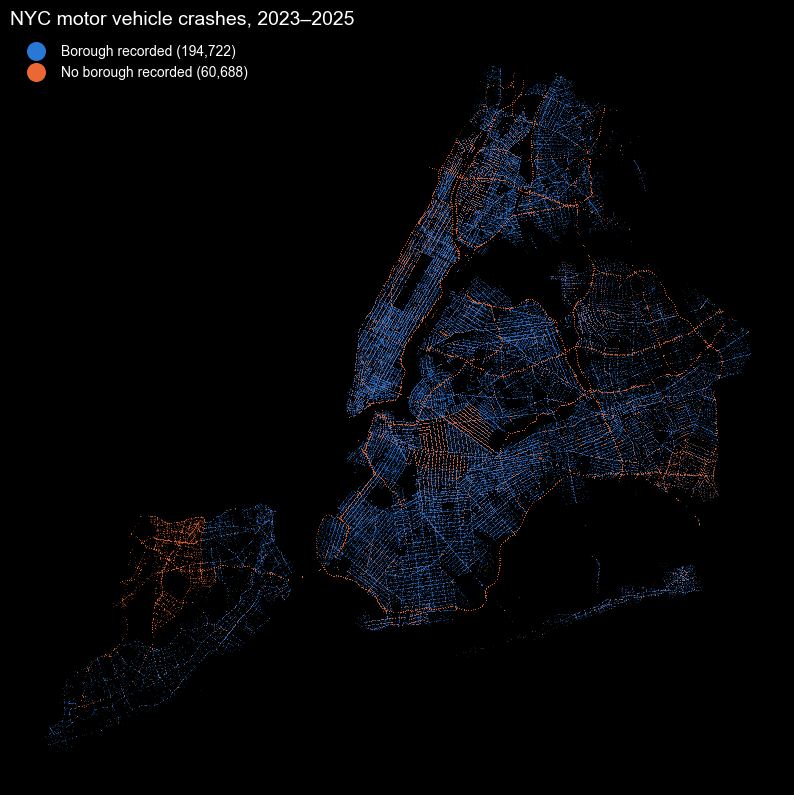

In [6]:
known = pts[pts["BOROUGH"].notna()]
missing = pts[pts["BOROUGH"].isna()]

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(known["LONGITUDE"], known["LATITUDE"], s=0.3, alpha=0.25, color="#2a78d6",
           linewidths=0, label=f"Borough recorded ({len(known):,})")
ax.scatter(missing["LONGITUDE"], missing["LATITUDE"], s=0.3, alpha=0.35, color="#eb6834",
           linewidths=0, label=f"No borough recorded ({len(missing):,})")

ax.set_aspect(1.3)      # stops NYC from looking stretched
ax.set_axis_off()       # no axes; the dots draw the city
ax.set_title("NYC motor vehicle crashes, 2023–2025", fontsize=14, loc="left")
leg = ax.legend(markerscale=25, loc="upper left", frameon=False)
for h in getattr(leg, "legend_handles", getattr(leg, "legendHandles", [])):
    h.set_alpha(1)      # make legend dots solid so they're readable

plt.savefig("nyc_crash_map.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()